## KIT719 Project 1: Developing an Information Retrieval Application Using NLTK 

### 1. Dataset Selection ###

Using the NLTK Reuters Corpus (Option 1).

In [1]:
import nltk

# Download the NLTK resources required by this notebook (safe to re-run).
for resource in [
    "reuters", "punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
    "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng",
]:
    nltk.download(resource, quiet=True)

# Load the Reuters Corpus
from nltk.corpus import reuters

doc_ids = reuters.fileids()
raw_texts = {d: reuters.raw(d) for d in doc_ids}          # doc_id -> raw text
categories_by_doc = {d: reuters.categories(d) for d in doc_ids}  # doc_id -> category labels

print(f"Documents loaded : {len(doc_ids)}")
print(f"Categories       : {len(reuters.categories())}")
print(f"Sample document  : {doc_ids[0]}")
print(raw_texts[doc_ids[0]][:200])

Documents loaded : 10788
Categories       : 90
Sample document  : test/14826
ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RIFT
  Mounting trade friction between the
  U.S. And Japan has raised fears among many of Asia's exporting
  nations that the row could inflict far-reachin


### 2. Text Preprocessing Module ###

Pipeline: lowercase conversion -> tokenisation -> punctuation/numeric-noise
filtering -> stopword removal -> normalisation (stemming or POS-aware lemmatisation).
Normalisation is a parameter (`none` / `stem` / `lemma`)

In [2]:
import string
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer

stop_words = set(stopwords.words("english"))
numeric_pattern = re.compile(r"^\d+([.,]\d+)?$")   # filters bare numbers (low retrieval value)
porter = PorterStemmer()
lemmatizer = WordNetLemmatizer()


def wordnet_pos(tag):
    '''Map a Penn Treebank POS tag to WordNet's POS format for accurate lemmatisation.'''
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


def preprocess(text, normalisation="lemma", remove_stopwords=True):
    '''Full preprocessing pipeline: tokenise, filter, normalise.'''
    text = text.lower()
    tokens = word_tokenize(text)

    # information filtering: remove punctuation, numbers, and non-alphabetic tokens
    tokens = [t for t in tokens if t not in string.punctuation]
    tokens = [t for t in tokens if not numeric_pattern.match(t)]
    tokens = [t for t in tokens if any(c.isalpha() for c in t)]

    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_words]

    if normalisation == "stem":
        tokens = [porter.stem(t) for t in tokens]
    elif normalisation == "lemma":
        tagged = nltk.pos_tag(tokens)
        tokens = [lemmatizer.lemmatize(t, wordnet_pos(tag)) for t, tag in tagged]

    return tokens


# Three normalisation strategies on the same document
print("lemma:", preprocess(raw_texts[doc_ids[0]], normalisation="lemma")[:15])
print("stem: ", preprocess(raw_texts[doc_ids[0]], normalisation="stem")[:15])
print("none: ", preprocess(raw_texts[doc_ids[0]], normalisation="none")[:15])

lemma: ['asian', 'exporter', 'fear', 'damage', 'u.s.-japan', 'rift', 'mount', 'trade', 'friction', 'u.s.', 'japan', 'raise', 'fear', 'among', 'many']
stem:  ['asian', 'export', 'fear', 'damag', 'u.s.-japan', 'rift', 'mount', 'trade', 'friction', 'u.s.', 'japan', 'rais', 'fear', 'among', 'mani']
none:  ['asian', 'exporters', 'fear', 'damage', 'u.s.-japan', 'rift', 'mounting', 'trade', 'friction', 'u.s.', 'japan', 'raised', 'fears', 'among', 'many']


### 3. Document Indexing ###

Two structures built from the same vocabulary:
- **Inverted index** — `term -> {doc_id: term_frequency}`, giving O(1) lookup
  of which documents contain a query term.
- **TF-IDF sparse matrix** — used by the cosine-similarity ranker for fast
  vectorised scoring.

In [3]:
from collections import defaultdict, Counter

tokenised_docs = [preprocess(raw_texts[d], normalisation="lemma") for d in doc_ids]


inverted_index = defaultdict(dict) # term -> {doc_id: term_frequency}
doc_len = {}   # doc_id -> number of tokens

for doc_id, tokens in zip(doc_ids, tokenised_docs):
    doc_len[doc_id] = len(tokens)
    tf = Counter(tokens)
    for term, freq in tf.items():
        inverted_index[term][doc_id] = freq

vocab = sorted(inverted_index.keys())
print(f"Vocabulary size: {len(vocab)} unique terms")
print(f"'grain' appears in {len(inverted_index['grain'])} documents")

Vocabulary size: 29866 unique terms
'grain' appears in 301 documents


In [4]:
def candidate_docs(query_terms, inverted_index):
    candidates = set()
    for term in query_terms:
        candidates.update(inverted_index.get(term, {}).keys())
    return candidates


sample_query = preprocess("grain trade policy", normalisation="lemma")
sample_candidates = candidate_docs(sample_query, inverted_index)
print(f"Query terms: {sample_query}")
print(f"Candidate documents: {len(sample_candidates)} (out of {len(doc_ids)} total)")

Query terms: ['grain', 'trade', 'policy']
Candidate documents: 1769 (out of 10788 total)


In [5]:
import numpy as np
from scipy import sparse

term_to_col = {t: i for i, t in enumerate(vocab)}
doc_id_to_row = {d: i for i, d in enumerate(doc_ids)}
N = len(doc_ids)

# smoothed inverse document frequency per term
idf = {}
for term in vocab:
    df = len(inverted_index[term])
    idf[term] = np.log((1 + N) / (1 + df)) + 1

# build the sparse TF-IDF matrix
rows, cols, data = [], [], []
for term in vocab:
    col = term_to_col[term]
    for doc_id, tf in inverted_index[term].items():
        rows.append(doc_id_to_row[doc_id])
        cols.append(col)
        data.append((1 + np.log(tf)) * idf[term])

tfidf_matrix = sparse.csr_matrix((data, (rows, cols)), shape=(N, len(vocab)))
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (10788, 29866)


### 4. Retrieval and Ranking ###

Two independent ranking methods:
- **TF-IDF + cosine similarity** — vector space model.
- **Okapi BM25** — probabilistic ranking function with document-length
  normalisation and term-frequency saturation (`k1 = 1.5`, `b = 0.75`).

In [6]:
from sklearn.preprocessing import normalize


def query_to_tfidf_vector(query_terms):
    """Project a preprocessed query onto the document TF-IDF vector space."""
    tf = Counter(query_terms)
    cols, data = [], []
    for term, freq in tf.items():
        if term in term_to_col:
            data.append((1 + np.log(freq)) * idf[term])
            cols.append(term_to_col[term])
    return sparse.csr_matrix((data, ([0] * len(cols), cols)), shape=(1, len(vocab)))


def rank_tfidf(query_terms, top_k=10):
    """Rank candidate documents by TF-IDF cosine similarity."""
    candidates = candidate_docs(query_terms, inverted_index)
    if not candidates:
        return []
    q_vec = normalize(query_to_tfidf_vector(query_terms))
    rows = [doc_id_to_row[d] for d in candidates]
    sub_matrix = normalize(tfidf_matrix[rows])
    scores = sub_matrix.dot(q_vec.T).toarray().ravel()
    ranked = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)
    return [(d, s) for d, s in ranked if s > 0][:top_k]

In [7]:
import math


def rank_bm25(query_terms, top_k=10, k1=1.5, b=0.75):
    candidates = candidate_docs(query_terms, inverted_index)
    if not candidates:
        return []

    avg_len = sum(doc_len.values()) / N
    scores = defaultdict(float)

    for term in set(query_terms):
        postings = inverted_index.get(term, {})
        if not postings:
            continue
        df = len(postings)
        term_idf = math.log(1 + (N - df + 0.5) / (df + 0.5))
        for doc_id, tf in postings.items():
            if doc_id not in candidates:
                continue
            dl = doc_len[doc_id]
            denom = tf + k1 * (1 - b + b * dl / avg_len)
            scores[doc_id] += term_idf * (tf * (k1 + 1)) / denom

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]

In [8]:
# compare both ranking methods on the same query
query_terms = preprocess("grain trade policy", normalisation="lemma")
results_tfidf = rank_tfidf(query_terms, top_k=5)
results_bm25 = rank_bm25(query_terms, top_k=5)

print("--- TF-IDF + Cosine Similarity ---")
for doc_id, score in results_tfidf:
    print(f"{doc_id:<15} {score:.4f}  {raw_texts[doc_id][:60].strip()}")

print("\n--- BM25 ---")
for doc_id, score in results_bm25:
    print(f"{doc_id:<15} {score:.4f}  {raw_texts[doc_id][:60].strip()}")

--- TF-IDF + Cosine Similarity ---
training/12558  0.3316  YEUTTER SAYS U.S. SHOULD STRESS TRADE NEGOTIATIONS AS LONG-T
training/2223   0.2771  WORLD GRAIN TRADE RECOVERY MAY BE UNDERWAY
  World grain tra
training/3311   0.2474  USDA ESTIMATES 1986/87 USSR GRAIN IMPORTS  26.0 MLN TONNES V
test/15842      0.2376  USDA ESTIMATES 1986/87 USSR GRAIN IMPORTS  28.0 MLN TONNES V
test/15844      0.2345  USDA ESTIMATES 1986 SOVIET GRAIN CROP  AT 210 MLN TONNES VS

--- BM25 ---
training/2223   13.8210  WORLD GRAIN TRADE RECOVERY MAY BE UNDERWAY
  World grain tra
training/5408   12.1866  EEP SHOULD BE USED TACTICALLY, YEUTTER SAYS
  U.S. Trade Rep
training/12558  10.4042  YEUTTER SAYS U.S. SHOULD STRESS TRADE NEGOTIATIONS AS LONG-T
training/11769  10.2173  CHINA OFFICIAL CONDEMNS GOVERNMENT GRAIN POLICY
  The grain
test/15710      10.0241  GRAIN SHIPS WAITING AT NEW ORLEANS
  Ten grain ships were lo


### 5. Query Processing Module ###

Pipeline: receive user input -> preprocess -> [spelling correction] ->
[query expansion] -> retrieve candidates -> rank -> display results.

Two query-processing techniques are supported:
- **Spelling correction** — replaces any out-of-vocabulary query term with the closest vocabulary term by Levenshtein edit distance.
- **Query expansion** — adds WordNet synonyms (already present in the vocabulary) to improve recall for differently-worded queries.

In [9]:
def corpus_term_frequency(term, index):
    """
    Return the total frequency of a term across the whole corpus.

    This is used as a deterministic tie-break when several spelling
    candidates have the same edit distance.
    """
    postings = index.get(term, {})
    return sum(postings.values())

def correct_spelling(query_terms, vocab, max_edit_distance=2, index=None):
    """
    Correct words that are not found in the current vocabulary.

    Candidate words are ranked by:
    1. smallest edit distance;
    2. highest corpus frequency;
    3. alphabetical order.

    Transpositions are enabled so common typing mistakes such as
    "grian" can be corrected to "grain".
    """
    
    vocab_set = set(vocab)
    if index is None:
        index = inverted_index
        
    corrected_terms = []
   
    for term in query_terms:
        # Keep words that already exist in the vocabulary.
        if term in vocab_set:
            corrected_terms.append(term)
            continue

        candidates = []

        for candidate in vocab_set:
            # Skip obviously unsuitable candidates before computing
            # the more expensive edit distance.
            length_difference = abs(
                len(candidate) - len(term)
            )

            if length_difference > max_edit_distance:
                continue

            distance = nltk.edit_distance(
                term,
                candidate,
                transpositions=True,
            )

            if distance > max_edit_distance:
                continue

            corpus_frequency = corpus_term_frequency(
                candidate,
                index,
            )

            candidates.append(
                (
                    distance,
                    -corpus_frequency,
                    candidate,
                )
            )

        if candidates:
            best_candidate = min(candidates)
            corrected_terms.append(
                best_candidate[2]
            )
        else:
            corrected_terms.append(term)

    return corrected_terms


def expand_query(query_terms, vocab, max_synonyms=2):
    """
    Expand query terms using WordNet synonyms.

    Only synonyms that already occur in the Reuters vocabulary are added.
    This prevents the system from adding words that cannot retrieve any
    document from the collection.

    Synonyms are sorted before selection so the behaviour is reproducible.
    """
    vocab_set = set(vocab)
    expanded_terms = list(query_terms)
    
    for term in query_terms:
        candidate_synonyms = set()

        for synset in wordnet.synsets(term):
            for lemma_name in synset.lemma_names():
                synonym = (
                    lemma_name
                    .lower()
                    .replace("_", " ")
                )

                if synonym == term:
                    continue

                if synonym not in vocab_set:
                    continue

                candidate_synonyms.add(synonym)

        selected_synonyms = sorted(
            candidate_synonyms
        )[:max_synonyms]

        expanded_terms.extend(
            selected_synonyms
        )

    # Remove duplicate terms while preserving their original order.
    unique_terms = list(
        dict.fromkeys(expanded_terms)
    )

    return unique_terms

def prepare_query(query, normalisation, use_spelling_correction, use_query_expansion, max_synonyms=2, vocab_source=None,
index_source=None):
    """
    Apply the complete query-processing pipeline.

    Pipeline:
    raw query
        -> preprocessing
        -> optional spelling correction
        -> optional WordNet query expansion
        -> final query terms
    """
    if vocab_source is None:
        vocab_source = vocab

    if index_source is None:
        index_source = inverted_index

    query_terms = preprocess(
        query,
        normalisation=normalisation,
    )

    if use_spelling_correction:
        query_terms = correct_spelling(
            query_terms,
            vocab_source,
            index=index_source,
        )

    if use_query_expansion:
        query_terms = expand_query(
            query_terms,
            vocab_source,
            max_synonyms=max_synonyms,
        )

    return query_terms

# Demonstrate each query-processing stage using a fixed typo example.
demo_query = "grian expotrs"

demo_without_expansion = prepare_query(
    demo_query,
    normalisation="lemma",
    use_spelling_correction=True,
    use_query_expansion=False,
)

demo_with_expansion = prepare_query(
    demo_query,
    normalisation="lemma",
    use_spelling_correction=True,
    use_query_expansion=True,
)

print("Query-processing demonstration")
print("Original query:", demo_query)
print("Without query expansion:", demo_without_expansion)
print("With query expansion   :", demo_with_expansion)



Query-processing demonstration
Original query: grian expotrs
Without query expansion: ['grain', 'export']
With query expansion   : ['grain', 'export', 'cereal', 'ingrain']


In [10]:
def tfidf_term_contributions(doc_id, query_terms):
    q_vec = normalize(query_to_tfidf_vector(query_terms))
    doc_row = doc_id_to_row[doc_id]
    d_vec = normalize(tfidf_matrix[doc_row])

    contributions = []

    for term in set(query_terms):
        if term not in term_to_col:
            continue

        col = term_to_col[term]

        q_weight = q_vec[0, col]
        d_weight = d_vec[0, col]

        contribution = float(q_weight * d_weight)

        if contribution > 0:
            contributions.append((term, contribution))

    return sorted(
        contributions,
        key=lambda x: x[1],
        reverse=True
    )



def bm25_term_contributions(doc_id, query_terms, k1=1.5, b=0.75):
    contributions = []

    avg_len = sum(doc_len.values()) / N
    dl = doc_len[doc_id]

    for term in set(query_terms):

        postings = inverted_index.get(term, {})

        if doc_id not in postings:
            continue

        tf = postings[doc_id]
        df = len(postings)

        term_idf = math.log(
            1 + (N - df + 0.5) / (df + 0.5)
        )

        denom = tf + k1 * (
            1 - b + b * dl / avg_len
        )

        score = (
            term_idf
            * (tf * (k1 + 1))
            / denom
        )

        contributions.append(
            (term, score, tf)
        )

    return sorted(
        contributions,
        key=lambda x: x[1],
        reverse=True
    )



def display_detailed_results(
    ranked,
    raw_texts,
    query_terms,
    method
):

    if not ranked:
        print("No relevant documents found.")
        return

    for i, (doc_id, score) in enumerate(ranked, start=1):

        text = raw_texts[doc_id].strip()

        lines = text.split("\n")
        title = lines[0].strip()

        # Short preview of document
        preview = " ".join(text.split())[:250]

        # Query terms that actually appear in this document
        matched_terms = [
            term
            for term in query_terms
            if doc_id in inverted_index.get(term, {})
        ]

        # Reuters categories
        categories = categories_by_doc.get(doc_id, [])

        print("\n" + "-" * 70)
        print(f"[{i}] {title}")

        print(f"Document ID : {doc_id}")

        print(
            "Categories  :",
            ", ".join(categories)
            if categories
            else "None"
        )

        if method == "tfidf":

            print(f"Similarity  : {score:.4f}")

            contributions = tfidf_term_contributions(
                doc_id,
                query_terms
            )

            print(
                "Matched     :",
                ", ".join(matched_terms)
                if matched_terms
                else "None"
            )

            print("\nTerm contribution:")

            for term, value in contributions:
                print(
                    f"  {term:<15} {value:.4f}"
                )

        else:

            print(f"BM25 Score  : {score:.4f}")

            contributions = bm25_term_contributions(
                doc_id,
                query_terms
            )

            print(
                "Matched     :",
                ", ".join(matched_terms)
                if matched_terms
                else "None"
            )

            print("\nScore contribution:")

            for term, value, tf in contributions:
                print(
                    f"  {term:<15} "
                    f"+{value:.4f} "
                    f"(TF={tf})"
                )

        print("\nPreview:")
        print(preview + "...")


***Console Application***


**Try to run the application at this part**



In [11]:
def run_console_app():

    print("=" * 70)
    print("KIT719 Information Retrieval System")
    print("=" * 70)

    print("Ranking methods:")
    print("  1. TF-IDF + Cosine Similarity")
    print("  2. Okapi BM25")
    print()

    print("Type a query, or 'exit' to quit.")

    while True:

        print("\n" + "=" * 70)

        query = input("User Query: ").strip()

        if query.lower() in ("exit", "quit"):
            print("Goodbye.")
            break

        if not query:
            continue


        # Query preprocessing

        original_terms = preprocess(
            query,
            normalisation="lemma"
        )

        corrected_terms = correct_spelling(
            original_terms,
            vocab
        )

        print("\nOriginal Query:")
        print(query)

        print("\nPreprocessed Query:")
        print(", ".join(original_terms))

        if corrected_terms != original_terms:

            print("\nAfter Spelling Correction:")
            print(", ".join(corrected_terms))

        terms = corrected_terms


        # TF-IDF

        tfidf_results = rank_tfidf(
            terms,
            top_k=5
        )

        print("\n")
        print("=" * 70)
        print("TF-IDF + COSINE SIMILARITY")
        print("=" * 70)

        display_detailed_results(
            tfidf_results,
            raw_texts,
            terms,
            method="tfidf"
        )


        # BM25
        
        bm25_results = rank_bm25(
            terms,
            top_k=5
        )

        print("\n")
        print("=" * 70)
        print("OKAPI BM25")
        print("=" * 70)

        display_detailed_results(
            bm25_results,
            raw_texts,
            terms,
            method="bm25"
        )




def demo_search(query, top_k=5):
    """Non-interactive version of the console app for a fixed query.
    This lets the notebook run end to end (Run All) without waiting for
    keyboard input, so the console-style output is reproduced automatically."""
    original_terms = preprocess(query, normalisation="lemma")
    corrected_terms = correct_spelling(original_terms, vocab)

    print("=" * 70)
    print("KIT719 Information Retrieval System (non-interactive demo)")
    print("=" * 70)
    print("User Query:", query)
    print("Preprocessed Query:", ", ".join(original_terms))
    if corrected_terms != original_terms:
        print("After Spelling Correction:", ", ".join(corrected_terms))

    terms = corrected_terms

    print("\n" + "=" * 70)
    print("TF-IDF + COSINE SIMILARITY")
    print("=" * 70)
    display_detailed_results(rank_tfidf(terms, top_k=top_k), raw_texts, terms, method="tfidf")

    print("\n" + "=" * 70)
    print("OKAPI BM25")
    print("=" * 70)
    display_detailed_results(rank_bm25(terms, top_k=top_k), raw_texts, terms, method="bm25")


# Interactive console: uncomment the next line to type your own queries.
# It waits for keyboard input, so it pauses "Run All" until you type 'exit'.
# run_console_app()

# Non-interactive demonstrations (run automatically during Run All):
demo_search("grain trade policy")
demo_search("I was walkin on Queens Street this morning and I saw a War Memorial.")

KIT719 Information Retrieval System (non-interactive demo)
User Query: grain trade policy
Preprocessed Query: grain, trade, policy

TF-IDF + COSINE SIMILARITY

----------------------------------------------------------------------
[1] YEUTTER SAYS U.S. SHOULD STRESS TRADE NEGOTIATIONS AS LONG-TERM U.S. TRADE POLICY
Document ID : training/12558
Categories  : trade
Similarity  : 0.3316
Matched     : trade, policy

Term contribution:
  policy          0.1829
  trade           0.1487

Preview:
YEUTTER SAYS U.S. SHOULD STRESS TRADE NEGOTIATIONS AS LONG-TERM U.S. TRADE POLICY YEUTTER SAYS U.S. SHOULD STRESS TRADE NEGOTIATIONS AS LONG-TERM U.S. TRADE POLICY...

----------------------------------------------------------------------
[2] WORLD GRAIN TRADE RECOVERY MAY BE UNDERWAY
Document ID : training/2223
Categories  : grain, wheat
Similarity  : 0.2771
Matched     : grain, trade, policy

Term contribution:
  grain           0.1563
  trade           0.0725
  policy          0.0482

Preview:
WOR

KIT719 Information Retrieval System (non-interactive demo)
User Query: I was walkin on Queens Street this morning and I saw a War Memorial.
Preprocessed Query: walkin, queen, street, morning, saw, war, memorial
After Spelling Correction: wallin, queen, street, morning, saw, war, memorial

TF-IDF + COSINE SIMILARITY



----------------------------------------------------------------------
[1] INTERNATIONAL DAIRY QUEEN &lt;INDQA> 1ST QTR NET
Document ID : training/11666
Categories  : earn
Similarity  : 0.2450
Matched     : queen

Term contribution:
  queen           0.2450

Preview:
INTERNATIONAL DAIRY QUEEN &lt;INDQA> 1ST QTR NET Ended February 28. Shr 18 cts vs 13 cts Net 1,706,601 vs 1,226,609 Rev 42.7 mln vs 36.3 mln Avg shares 9,695,444 vs 9,537,043 NOTE: Company's full name is International Dairy Queen Inc....

----------------------------------------------------------------------
[2] MEDTRONIC &lt;MDT> SEES 15 PCT EARNINGS GROWTH
Document ID : test/15213
Categories  : earn
Similarity  : 0.1511
Matched     : wallin

Term contribution:
  wallin          0.1511

Preview:
MEDTRONIC &lt;MDT> SEES 15 PCT EARNINGS GROWTH Medtronic Inc said it sees 15 pct growth in sales and earnings for the year ending April 30, 1988. At an analysts meeting here the company said that for the year ending April 30, 198

### 6. Performance Evaluation ###

**Metrics:** Precision@10 and Recall@10 (top-of-ranking quality), F1@10
(balance of the two), and Mean Average Precision - MAP (rewards relevant
documents appearing early in the ranking, not just present in the top 10).

**Experiment:** all combinations of 3 preprocessing strategies (none / stem /
lemma) x 2 ranking methods (TF-IDF / BM25) are compared, giving 6 base
configurations. The same 6 configurations are then re-run with WordNet query
expansion turned on, so the effect of query expansion is measured rather than
assumed.

In [12]:
docs_by_category = defaultdict(set)
for d, cats in categories_by_doc.items():
    for c in cats:
        docs_by_category[c].add(d)


def precision_recall_f1_at_k(ranked_doc_ids, relevant_set, k=10):
    top_k = ranked_doc_ids[:k]
    if not top_k:
        return 0.0, 0.0, 0.0
    hits = sum(1 for d in top_k if d in relevant_set)
    precision = hits / len(top_k)
    recall = hits / len(relevant_set) if relevant_set else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


def average_precision(ranked_doc_ids, relevant_set, k=50):
    top_k = ranked_doc_ids[:k]
    if not relevant_set:
        return 0.0
    hits, ap_sum = 0, 0.0
    for i, d in enumerate(top_k, start=1):
        if d in relevant_set:
            hits += 1
            ap_sum += hits / i
    return ap_sum / min(len(relevant_set), k) if hits else 0.0


print("Evaluation functions defined.")

Evaluation functions defined.


In [13]:
TEST_CATEGORIES = [
    "earn", "acq", "money-fx", "grain", "crude", "trade", "interest",
    "ship", "wheat", "corn", "money-supply", "oilseed", "sugar", "coffee"
]


def build_evaluation_index(normalisation):
    """
    Build all structures required to evaluate one preprocessing strategy.

    The TF-IDF representation intentionally follows the same weighting and
    cosine-normalisation definition used by the deployed rank_tfidf function.
    """
    tokenised = [
        preprocess(raw_texts[d], normalisation=normalisation)
        for d in doc_ids
    ]

    index = defaultdict(dict)
    lengths = {}

    for doc_id, tokens in zip(doc_ids, tokenised):
        lengths[doc_id] = len(tokens)
        for term, freq in Counter(tokens).items():
            index[term][doc_id] = freq

    local_vocab = sorted(index.keys())
    term_to_col_local = {term: i for i, term in enumerate(local_vocab)}
    doc_to_row_local = {doc_id: i for i, doc_id in enumerate(doc_ids)}

    local_idf = {}
    for term in local_vocab:
        df = len(index[term])
        local_idf[term] = np.log((1 + N) / (1 + df)) + 1

    rows, cols, data = [], [], []
    for term in local_vocab:
        col = term_to_col_local[term]
        for doc_id, tf in index[term].items():
            rows.append(doc_to_row_local[doc_id])
            cols.append(col)
            data.append((1 + np.log(tf)) * local_idf[term])

    matrix = sparse.csr_matrix(
        (data, (rows, cols)),
        shape=(N, len(local_vocab))
    )

    # Normalise once at build time. Dot product with a normalised query vector
    # is then exactly cosine similarity.
    matrix_norm = normalize(matrix, norm="l2", axis=1)

    return {
        "inverted_index": index,
        "doc_len": lengths,
        "vocab": local_vocab,
        "term_to_col": term_to_col_local,
        "doc_to_row": doc_to_row_local,
        "idf": local_idf,
        "tfidf_matrix_norm": matrix_norm,
        "avg_doc_len": sum(lengths.values()) / N,
    }


def rank_tfidf_from_index(query_terms, structures, top_k=10):
    """TF-IDF cosine ranking using the same definition as rank_tfidf()."""
    index = structures["inverted_index"]
    candidates = candidate_docs(query_terms, index)
    if not candidates:
        return []

    term_to_col_local = structures["term_to_col"]
    local_idf = structures["idf"]

    q_tf = Counter(query_terms)
    q_cols, q_data = [], []

    for term, freq in q_tf.items():
        if term in term_to_col_local:
            q_cols.append(term_to_col_local[term])
            q_data.append((1 + np.log(freq)) * local_idf[term])

    if not q_cols:
        return []

    q_vec = sparse.csr_matrix(
        (q_data, ([0] * len(q_cols), q_cols)),
        shape=(1, len(structures["vocab"]))
    )
    q_vec = normalize(q_vec, norm="l2", axis=1)

    candidate_list = sorted(candidates)
    rows = [structures["doc_to_row"][d] for d in candidate_list]
    sub_matrix = structures["tfidf_matrix_norm"][rows]

    scores = sub_matrix.dot(q_vec.T).toarray().ravel()
    ranked = sorted(
        zip(candidate_list, scores),
        key=lambda x: (-x[1], x[0])
    )

    return [(d, float(s)) for d, s in ranked if s > 0][:top_k]


def rank_bm25_from_index(query_terms, structures, top_k=10, k1=1.5, b=0.75):
    """BM25 ranking equivalent to the deployed rank_bm25() definition."""
    index = structures["inverted_index"]
    candidates = candidate_docs(query_terms, index)
    if not candidates:
        return []

    lengths = structures["doc_len"]
    avg_len = structures["avg_doc_len"]
    scores = defaultdict(float)

    for term in sorted(set(query_terms)):
        postings = index.get(term, {})
        if not postings:
            continue

        df = len(postings)
        term_idf = math.log(1 + (N - df + 0.5) / (df + 0.5))

        for doc_id, tf in postings.items():
            if doc_id not in candidates:
                continue

            dl = lengths[doc_id]
            denom = tf + k1 * (1 - b + b * dl / avg_len)
            scores[doc_id] += (
                term_idf * (tf * (k1 + 1)) / denom
            )

    return sorted(
        scores.items(),
        key=lambda x: (-x[1], x[0])
    )[:top_k]


# Compare six base configurations (expansion off) and the same six with
# WordNet query expansion turned on. The base results reproduce Table 1.
results = []
results_expanded = []

for norm in ("none", "stem", "lemma"):
    structures = build_evaluation_index(norm)
    local_vocab = structures["vocab"]

    for ranker_name in ("tfidf", "bm25"):
        for use_expansion in (False, True):
            p_list, r_list, f1_list, ap_list = [], [], [], []

            for cat in TEST_CATEGORIES:
                relevant = docs_by_category.get(cat, set())
                if not relevant:
                    continue

                terms = preprocess(cat.replace("-", " "), normalisation=norm)
                if use_expansion:
                    terms = expand_query(terms, local_vocab)

                if ranker_name == "tfidf":
                    ranked = rank_tfidf_from_index(terms, structures, top_k=50)
                else:
                    ranked = rank_bm25_from_index(terms, structures, top_k=50)

                ranked_ids = [doc_id for doc_id, _ in ranked]

                p, r, f1 = precision_recall_f1_at_k(ranked_ids, relevant, k=10)
                ap = average_precision(ranked_ids, relevant, k=50)

                p_list.append(p)
                r_list.append(r)
                f1_list.append(f1)
                ap_list.append(ap)

            row = {
                "normalisation": norm,
                "ranker": ranker_name,
                "expansion": "on" if use_expansion else "off",
                "precision@10": float(np.mean(p_list)) if p_list else 0.0,
                "recall@10": float(np.mean(r_list)) if r_list else 0.0,
                "f1@10": float(np.mean(f1_list)) if f1_list else 0.0,
                "MAP": float(np.mean(ap_list)) if ap_list else 0.0,
            }

            if use_expansion:
                results_expanded.append(row)
            else:
                results.append(row)

print("Evaluation complete: 6 base configurations and 6 query-expansion configurations.")

Evaluation complete: 6 base configurations and 6 query-expansion configurations.


In [14]:
print(f"{'Preprocessing':<15}{'Ranker':<10}{'Precision@10':<14}{'Recall@10':<12}{'F1@10':<10}{'MAP':<10}")
for r in results:
    print(f"{r['normalisation']:<15}{r['ranker']:<10}{r['precision@10']:<14.3f}"
          f"{r['recall@10']:<12.3f}{r['f1@10']:<10.3f}{r['MAP']:<10.3f}")

Preprocessing  Ranker    Precision@10  Recall@10   F1@10     MAP       
none           tfidf     0.786         0.030       0.057     0.658     
none           bm25      0.807         0.031       0.059     0.675     
stem           tfidf     0.857         0.031       0.060     0.726     
stem           bm25      0.836         0.031       0.059     0.739     
lemma          tfidf     0.857         0.031       0.059     0.714     
lemma          bm25      0.836         0.031       0.059     0.727     


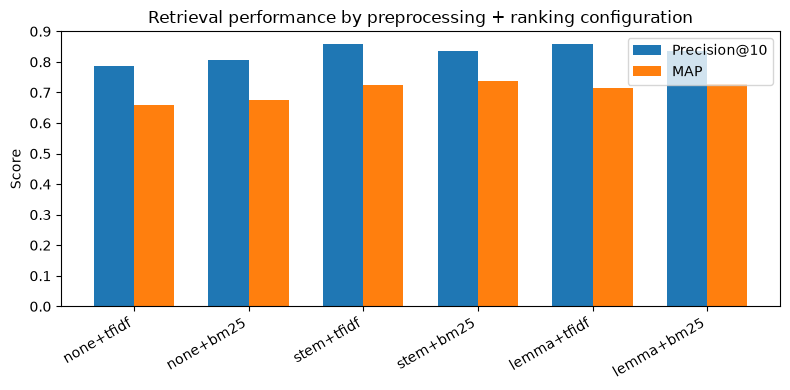

In [15]:
import matplotlib.pyplot as plt

configs = [f"{r['normalisation']}+{r['ranker']}" for r in results]
p_scores = [r['precision@10'] for r in results]
map_scores = [r['MAP'] for r in results]

x = np.arange(len(configs))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, p_scores, width, label="Precision@10")
ax.bar(x + width / 2, map_scores, width, label="MAP")
ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=30, ha="right")
ax.set_ylabel("Score")
ax.set_title("Retrieval performance by preprocessing + ranking configuration")
ax.legend()
plt.tight_layout()
plt.show()

**Query expansion comparison**

The table and chart below compare each configuration with query expansion
turned off and on, using the same category queries and relevance judgements.
Because the evaluation queries are single category words, this is a controlled
test of expansion on short queries.

In [16]:
# Effect of query expansion: MAP and Precision@10 with expansion off vs on.
print(f"{'Preprocessing':<15}{'Ranker':<8}{'MAP off':<10}{'MAP on':<10}{'P@10 off':<11}{'P@10 on':<10}")
for base, exp in zip(results, results_expanded):
    print(f"{base['normalisation']:<15}{base['ranker']:<8}"
          f"{base['MAP']:<10.3f}{exp['MAP']:<10.3f}"
          f"{base['precision@10']:<11.3f}{exp['precision@10']:<10.3f}")

Preprocessing  Ranker  MAP off   MAP on    P@10 off   P@10 on   
none           tfidf   0.658     0.529     0.786      0.621     
none           bm25    0.675     0.519     0.807      0.614     
stem           tfidf   0.726     0.622     0.857      0.729     
stem           bm25    0.739     0.625     0.836      0.700     
lemma          tfidf   0.714     0.586     0.857      0.686     
lemma          bm25    0.727     0.601     0.836      0.664     


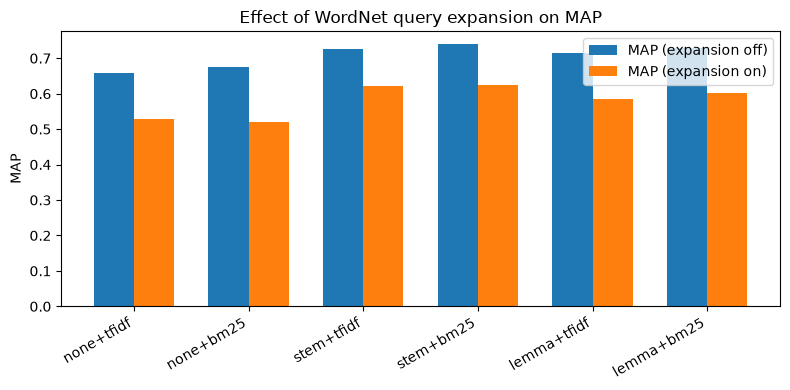

In [17]:
configs = [f"{r['normalisation']}+{r['ranker']}" for r in results]
map_off = [r['MAP'] for r in results]
map_on = [r['MAP'] for r in results_expanded]

x = np.arange(len(configs))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, map_off, width, label="MAP (expansion off)")
ax.bar(x + width / 2, map_on, width, label="MAP (expansion on)")
ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=30, ha="right")
ax.set_ylabel("MAP")
ax.set_title("Effect of WordNet query expansion on MAP")
ax.legend()
plt.tight_layout()
plt.show()